Removed 45 listed outlier files.
Loaded surface 1462
Remaining nuclei: 656
Using FINAL_K = 2
Surface 1462
Number of nuclei: 656
Median profile length used for resampling: 16

Primary clustering: profile shape only
Column: cluster_geom_only_k2
Silhouette: 0.288
Explained variance ratio:
[0.28073194 0.27191207 0.14366024 0.12689291 0.05743891]
Explained variance sum: 0.881

Cluster summary, primary geometry-only labels:


,cluster_geom_only_k2,count,mean,std,median,min,max
0,0,383,16.127937,2.899147,16.0,8,31
1,1,273,16.912088,2.824453,17.0,9,30


Kruskal-Wallis p for profile length across geometry-only clusters: 1.037e-04

Sensitivity clustering: profile shape + original profile length
Column: cluster_geom_plus_length_k2
Silhouette: 0.271

Cluster summary, profile-shape-plus-length labels:


,cluster_geom_plus_length_k2,count,mean,std,median,min,max
0,0,344,16.860465,2.943245,17.0,9,31
1,1,312,16.006410,2.770995,16.0,8,26


Kruskal-Wallis p for profile length across shape+length clusters: 2.641e-04

Agreement between primary and length-including clustering:
Adjusted Rand Index: 0.613


...

c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warnin

,model,macro_f1_mean,macro_f1_std,n_splits
0,length_only_logistic,0.566939,0.027099,5
1,majority_dummy,0.368621,0.001364,5



Can profile length alone predict length-including clusters?


c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warnin

,model,macro_f1_mean,macro_f1_std,n_splits
0,length_only_logistic,0.554532,0.049847,5
1,majority_dummy,0.343998,0.001324,5


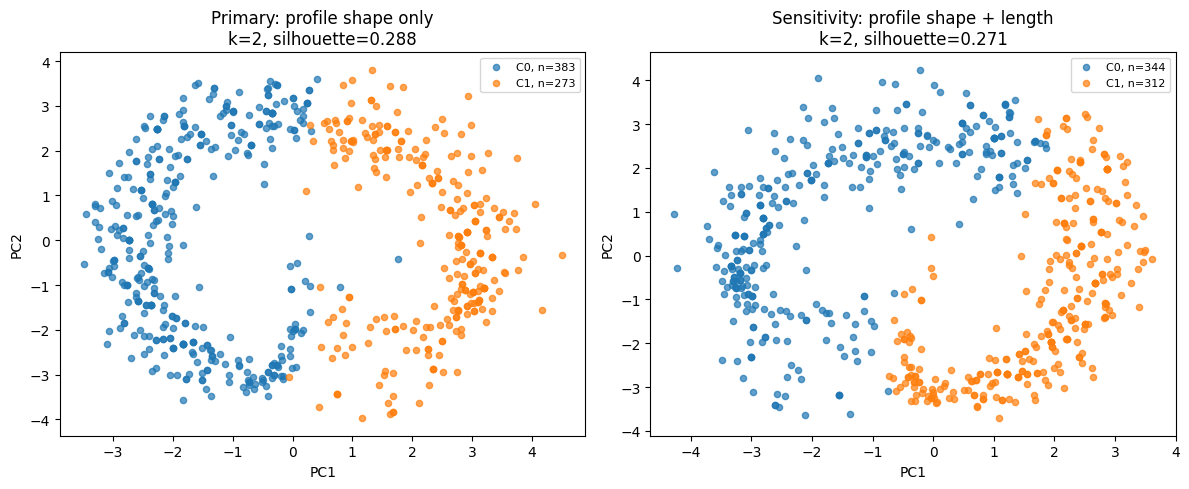

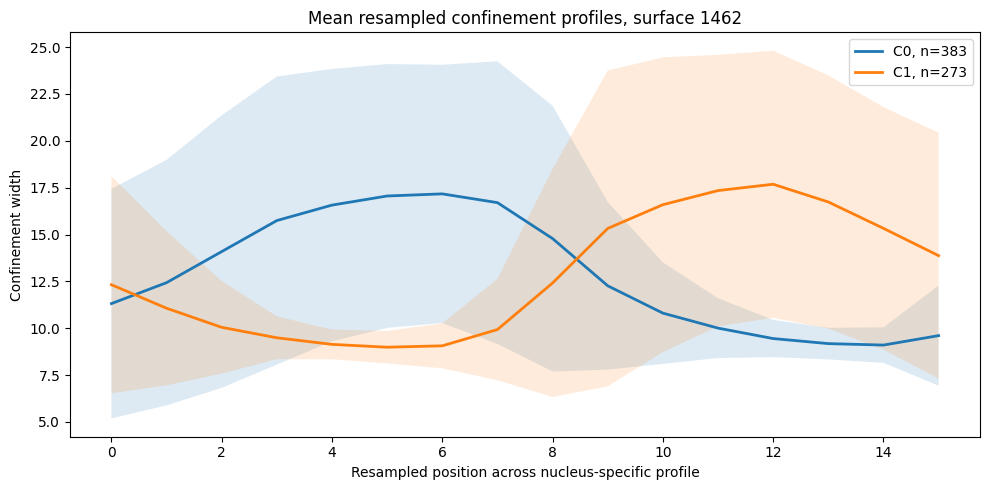


Saved: datasets/combined_clustered_data_1462_geom_only_k2.csv
Use this as the main cluster column: cluster_geom_only_k2
Keep this as the sensitivity/control column: cluster_geom_plus_length_k2


In [4]:
# ============================================================
# Circularity-safe pseudolocation clustering
# Primary clustering excludes original profile length.
# Length is evaluated only as a sensitivity/control variable.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from scipy.stats import kruskal



# ============================================================
# Load surface-specific pseudolocation dataframe
# Run this BEFORE the circularity-safe clustering block
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================

SURFACE_ID = "1462"   # or "1462"

if SURFACE_ID == "1462":
    FINAL_K = 2
elif SURFACE_ID == "1476":
    FINAL_K = 2
else:
    raise ValueError("SURFACE_ID must be '1462' or '1476'")

N_PCS_CLUSTER = 5
RANDOM_STATE = 42
MIN_PROFILE_LENGTH = 6

# Load original pseudolocation dataframe
SD_clean = pd.read_pickle(f"checkpoints/pseudotime_cells_clean_{SURFACE_ID}.pkl")

# Keep only nuclei with enough confinement-width measurements
MIN_PROFILE_LENGTH = 6

SD_clean = SD_clean[
    SD_clean["pseudotime_widths"].apply(lambda x: len(x) >= MIN_PROFILE_LENGTH)
].copy()

# Remove visually identified segmentation/registration outliers
outlier_path = Path(f"datasets/{SURFACE_ID}_dapi_python_segmentation_outliers.txt")

if outlier_path.exists():
    with open(outlier_path, "r") as f:
        outliers = [line.strip() + ".tif" for line in f if line.strip()]

    SD_clean = SD_clean[
        ~SD_clean["path_dapi"].apply(lambda p: Path(p).name).isin(outliers)
    ].copy()

    print(f"Removed {len(outliers)} listed outlier files.")
else:
    print(f"No outlier file found at: {outlier_path}")

# This was commented out in your original notebook, but old cells depend on X.
# The new clustering block does not strictly need X, but defining it avoids later errors.
X = SD_clean["pseudotime_widths"].to_list()

print(f"Loaded surface {SURFACE_ID}")
print(f"Remaining nuclei: {len(SD_clean)}")
print(f"Using FINAL_K = {FINAL_K}")
SD_clean.head()
df = SD_clean.copy()

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def parse_profile(x):
    """
    Robustly convert pseudotime_widths values into numpy arrays.
    Handles lists, arrays, and string-stored arrays.
    """
    if isinstance(x, np.ndarray):
        return x.astype(float)

    if isinstance(x, list):
        return np.asarray(x, dtype=float)

    if isinstance(x, str):
        s = (
            x.replace("\n", " ")
             .replace(",", " ")
             .replace("[", " ")
             .replace("]", " ")
             .strip()
        )
        if s == "":
            return np.array([], dtype=float)
        return np.fromstring(s, sep=" ", dtype=float)

    if pd.isna(x):
        return np.array([], dtype=float)

    return np.asarray(x, dtype=float)


def resample_ts_raw(ts, target_len):
    """
    Resample one nucleus-specific confinement profile to a fixed length.
    This preserves profile shape but removes original profile length
    as an explicit clustering feature.
    """
    ts = np.asarray(ts, dtype=float)

    if len(ts) < 2:
        return np.full(target_len, np.nan)

    x_old = np.linspace(0, 1, len(ts))
    x_new = np.linspace(0, 1, target_len)

    return np.interp(x_new, x_old, ts)


def cluster_profiles(X, k, n_pcs=5):
    """
    Scale, PCA-transform, and cluster profile matrix.
    """
    X_scaled = StandardScaler().fit_transform(X)

    n_components = min(n_pcs, X_scaled.shape[1], X_scaled.shape[0] - 1)
    pca = PCA(n_components=n_components, svd_solver="full", random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)

    labels = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    ).fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels)

    return labels, X_pca, pca, sil


def summarize_clusters(df, cluster_col, length_col="profile_length"):
    """
    Summarize cluster sizes and profile-length distributions.
    """
    summary = (
        df.groupby(cluster_col)[length_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )

    groups = [
        df.loc[df[cluster_col] == c, length_col].dropna().values
        for c in sorted(df[cluster_col].dropna().unique())
    ]

    if len(groups) > 1 and all(len(g) > 0 for g in groups):
        kw_stat, kw_p = kruskal(*groups)
    else:
        kw_stat, kw_p = np.nan, np.nan

    return summary, kw_p


def length_only_predictability(df, cluster_col, length_col="profile_length"):
    """
    Tests whether cluster labels can be predicted from profile length alone.
    If this score is high, cluster labels are strongly length/size-associated.
    """
    tmp = df[[cluster_col, length_col]].dropna().copy()

    X_len = tmp[[length_col]].to_numpy()
    y = tmp[cluster_col].to_numpy()

    class_counts = pd.Series(y).value_counts()
    min_class_count = class_counts.min()

    if min_class_count < 2:
        print(f"Not enough samples per class for CV: {class_counts.to_dict()}")
        return None

    n_splits = min(5, min_class_count)

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    length_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            multi_class="auto",
            random_state=RANDOM_STATE
        )
    )

    dummy_model = DummyClassifier(
        strategy="most_frequent",
        random_state=RANDOM_STATE
    )

    length_scores = cross_val_score(
        length_model,
        X_len,
        y,
        cv=cv,
        scoring="f1_macro"
    )

    dummy_scores = cross_val_score(
        dummy_model,
        X_len,
        y,
        cv=cv,
        scoring="f1_macro"
    )

    return pd.DataFrame({
        "model": ["length_only_logistic", "majority_dummy"],
        "macro_f1_mean": [length_scores.mean(), dummy_scores.mean()],
        "macro_f1_std": [length_scores.std(), dummy_scores.std()],
        "n_splits": [n_splits, n_splits]
    })


# ------------------------------------------------------------
# 1. Build confinement-profile matrix
# ------------------------------------------------------------
profiles = df["pseudotime_widths"].apply(parse_profile)

valid_mask = profiles.apply(lambda x: len(x) >= 2)
df = df.loc[valid_mask].copy()
profiles = profiles.loc[valid_mask]

lengths = profiles.apply(len).to_numpy()
df["profile_length"] = lengths

target_len = int(np.median(lengths))
print(f"Surface {SURFACE_ID}")
print(f"Number of nuclei: {len(df)}")
print(f"Median profile length used for resampling: {target_len}")

X_shape = np.vstack([
    resample_ts_raw(ts, target_len)
    for ts in profiles
])

# Safety check
if np.isnan(X_shape).any():
    raise ValueError("NaNs detected in resampled profiles. Check short or malformed profiles.")

# ------------------------------------------------------------
# 2. PRIMARY clustering: geometry/profile-shape only
# ------------------------------------------------------------
labels_geom_only, X_pca_geom_only, pca_geom_only, sil_geom_only = cluster_profiles(
    X_shape,
    k=FINAL_K,
    n_pcs=N_PCS_CLUSTER
)

geom_col = f"cluster_geom_only_k{FINAL_K}"
df[geom_col] = labels_geom_only

print("\nPrimary clustering: profile shape only")
print(f"Column: {geom_col}")
print(f"Silhouette: {sil_geom_only:.3f}")
print("Explained variance ratio:")
print(pca_geom_only.explained_variance_ratio_)
print(f"Explained variance sum: {pca_geom_only.explained_variance_ratio_.sum():.3f}")

geom_summary, geom_length_kw_p = summarize_clusters(df, geom_col)

print("\nCluster summary, primary geometry-only labels:")
display(geom_summary)
print(f"Kruskal-Wallis p for profile length across geometry-only clusters: {geom_length_kw_p:.3e}")

# ------------------------------------------------------------
# 3. SENSITIVITY clustering: profile shape + original length
# ------------------------------------------------------------
X_shape_plus_length = np.hstack([
    X_shape,
    lengths.astype(float).reshape(-1, 1)
])

labels_with_length, X_pca_with_length, pca_with_length, sil_with_length = cluster_profiles(
    X_shape_plus_length,
    k=FINAL_K,
    n_pcs=N_PCS_CLUSTER
)

with_len_col = f"cluster_geom_plus_length_k{FINAL_K}"
df[with_len_col] = labels_with_length

print("\nSensitivity clustering: profile shape + original profile length")
print(f"Column: {with_len_col}")
print(f"Silhouette: {sil_with_length:.3f}")

with_len_summary, with_len_kw_p = summarize_clusters(df, with_len_col)

print("\nCluster summary, profile-shape-plus-length labels:")
display(with_len_summary)
print(f"Kruskal-Wallis p for profile length across shape+length clusters: {with_len_kw_p:.3e}")

# ------------------------------------------------------------
# 4. Compare primary vs length-including labels
# ------------------------------------------------------------
ari = adjusted_rand_score(df[geom_col], df[with_len_col])

print("\nAgreement between primary and length-including clustering:")
print(f"Adjusted Rand Index: {ari:.3f}")

comparison_table = pd.crosstab(
    df[geom_col],
    df[with_len_col],
    rownames=[geom_col],
    colnames=[with_len_col]
)

display(comparison_table)

# ------------------------------------------------------------
# 5. Test whether profile length alone predicts clusters
# ------------------------------------------------------------
print("\nCan profile length alone predict primary geometry-only clusters?")
length_predictability_geom = length_only_predictability(df, geom_col)
display(length_predictability_geom)

print("\nCan profile length alone predict length-including clusters?")
length_predictability_with_len = length_only_predictability(df, with_len_col)
display(length_predictability_with_len)

# ------------------------------------------------------------
# 6. PCA plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

for c in sorted(df[geom_col].unique()):
    idx = df[geom_col].to_numpy() == c
    axes[0].scatter(
        X_pca_geom_only[idx, 0],
        X_pca_geom_only[idx, 1],
        s=20,
        alpha=0.7,
        label=f"C{c}, n={idx.sum()}"
    )

axes[0].set_title(f"Primary: profile shape only\nk={FINAL_K}, silhouette={sil_geom_only:.3f}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=8)

for c in sorted(df[with_len_col].unique()):
    idx = df[with_len_col].to_numpy() == c
    axes[1].scatter(
        X_pca_with_length[idx, 0],
        X_pca_with_length[idx, 1],
        s=20,
        alpha=0.7,
        label=f"C{c}, n={idx.sum()}"
    )

axes[1].set_title(f"Sensitivity: profile shape + length\nk={FINAL_K}, silhouette={sil_with_length:.3f}")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Mean confinement profiles per primary cluster
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

for c in sorted(df[geom_col].unique()):
    idx = df[geom_col].to_numpy() == c
    cluster_mat = X_shape[idx]

    mean_profile = np.nanmean(cluster_mat, axis=0)
    std_profile = np.nanstd(cluster_mat, axis=0)
    x = np.arange(target_len)

    plt.plot(x, mean_profile, linewidth=2, label=f"C{c}, n={idx.sum()}")
    plt.fill_between(
        x,
        mean_profile - std_profile,
        mean_profile + std_profile,
        alpha=0.15
    )

plt.title(f"Mean resampled confinement profiles, surface {SURFACE_ID}")
plt.xlabel("Resampled position across nucleus-specific profile")
plt.ylabel("Confinement width")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Save back to SD_clean-compatible object
# ------------------------------------------------------------
# This keeps the primary geometry-only labels and the sensitivity labels.
# Use geom_col as the main manuscript clustering column.
SD_clean = df.copy()

output_path = f"datasets/combined_clustered_data_{SURFACE_ID}_geom_only_k{FINAL_K}.csv"
SD_clean.to_csv(output_path, index=False)

print(f"\nSaved: {output_path}")
print(f"Use this as the main cluster column: {geom_col}")
print(f"Keep this as the sensitivity/control column: {with_len_col}")

In [3]:
summary_row = pd.DataFrame([{
    "surface": SURFACE_ID,
    "k": FINAL_K,
    "n_nuclei": len(df),
    "primary_label": geom_col,
    "sensitivity_label": with_len_col,
    "silhouette_geom_only": sil_geom_only,
    "silhouette_geom_plus_length": sil_with_length,
    "ARI_geom_vs_plus_length": ari,
    "profile_length_kw_p_geom_only": geom_length_kw_p,
    "profile_length_kw_p_plus_length": with_len_kw_p,
    "length_only_macro_f1_geom_only": length_predictability_geom.loc[
        length_predictability_geom["model"] == "length_only_logistic",
        "macro_f1_mean"
    ].iloc[0],
    "dummy_macro_f1_geom_only": length_predictability_geom.loc[
        length_predictability_geom["model"] == "majority_dummy",
        "macro_f1_mean"
    ].iloc[0],
    "length_only_macro_f1_plus_length": length_predictability_with_len.loc[
        length_predictability_with_len["model"] == "length_only_logistic",
        "macro_f1_mean"
    ].iloc[0],
    "dummy_macro_f1_plus_length": length_predictability_with_len.loc[
        length_predictability_with_len["model"] == "majority_dummy",
        "macro_f1_mean"
    ].iloc[0],
}])

display(summary_row)

summary_row.to_csv(
    f"datasets/clustering_length_control_summary_{SURFACE_ID}.csv",
    index=False
)

,surface,k,n_nuclei,primary_label,sensitivity_label,silhouette_geom_only,silhouette_geom_plus_length,ARI_geom_vs_plus_length,profile_length_kw_p_geom_only,profile_length_kw_p_plus_length,length_only_macro_f1_geom_only,dummy_macro_f1_geom_only,length_only_macro_f1_plus_length,dummy_macro_f1_plus_length
0,1476,2,878,cluster_geom_only_k2,cluster_geom_plus_length_k2,0.323251,0.343346,0.619642,0.013511,5.105071e-07,0.518987,0.42913,0.57297,0.393227


In [7]:
# ============================================================
# Export ML-ready CSVs with geometry-only k=2 labels
# Same structure as merged_filtered_data_for_Danya_clean.csv
#
# Main idea:
# - k = 2 for both 1462 and 1476
# - clustering uses only resampled pseudotime_widths profile shape
# - original profile length is NOT used for clustering
# - no profile_length / orig_len column is exported
# - outputs are CSV files only
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score


# ============================================================
# SETTINGS
# ============================================================

ROOT = Path(".")

SURFACES = ["1462", "1476"]

FINAL_K = 2
N_PCS_CLUSTER = 5
MIN_PROFILE_LENGTH = 6
RANDOM_STATE = 42

# Your old/reference file
# Put the file in one of these locations, or adjust the path manually.
REFERENCE_CSV_CANDIDATES = [
    ROOT / "datasets" / "for Danya ML" / "merged_filtered_data_for_Danya_clean.csv",
    ROOT / "datasets" / "merged_filtered_data_for_Danya_clean.csv",
]

OUTPUT_MAIN = ROOT / "datasets" / "merged_filtered_data_for_Danya_geom_only_k2_clean.csv"
OUTPUT_NO_OBVIOUS_SHAPE = ROOT / "datasets" / "merged_filtered_data_for_Danya_geom_only_k2_no_obvious_size_shape.csv"
OUTPUT_NO_AREASHAPE = ROOT / "datasets" / "merged_filtered_data_for_Danya_geom_only_k2_no_areashape.csv"
OUTPUT_SUMMARY = ROOT / "datasets" / "geom_only_k2_ml_dataset_summary.csv"
OUTPUT_FEATURE_SETS = ROOT / "datasets" / "geom_only_k2_ml_feature_sets.csv"


# ============================================================
# Helper functions
# ============================================================

def find_reference_csv():
    for path in REFERENCE_CSV_CANDIDATES:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Could not find merged_filtered_data_for_Danya_clean.csv. "
        "Place it in the project root or datasets folder, or edit REFERENCE_CSV_CANDIDATES."
    )


def parse_profile(x):
    """
    Converts list/array/string-stored profile into a numeric numpy array.
    """
    if isinstance(x, np.ndarray):
        return x.astype(float)

    if isinstance(x, list):
        return np.asarray(x, dtype=float)

    if isinstance(x, str):
        s = (
            x.replace("\n", " ")
             .replace(",", " ")
             .replace("[", " ")
             .replace("]", " ")
             .strip()
        )
        if s == "":
            return np.array([], dtype=float)
        return np.fromstring(s, sep=" ", dtype=float)

    if pd.isna(x):
        return np.array([], dtype=float)

    return np.asarray(x, dtype=float)


def resample_ts_raw(ts, target_len):
    """
    Resample one confinement-width profile to a fixed length.
    Original profile length is NOT appended as a feature.
    """
    ts = np.asarray(ts, dtype=float)

    if len(ts) < 2:
        return np.full(target_len, np.nan)

    x_old = np.linspace(0, 1, len(ts))
    x_new = np.linspace(0, 1, target_len)

    return np.interp(x_new, x_old, ts)


def cluster_geometry_only_k2(df, width_col="pseudotime_widths"):
    """
    Geometry-only clustering:
    - uses only resampled confinement-profile shape
    - does NOT use original profile length
    - returns dataframe with cluster_agg_k
    """
    profiles = df[width_col].apply(parse_profile)

    valid_mask = profiles.apply(lambda x: len(x) >= MIN_PROFILE_LENGTH)

    if not valid_mask.all():
        print(f"Removing {(~valid_mask).sum()} rows with profile length < {MIN_PROFILE_LENGTH}")
        df = df.loc[valid_mask].copy()
        profiles = profiles.loc[valid_mask]

    lengths = profiles.apply(len).to_numpy()
    target_len = int(np.median(lengths))

    X_shape = np.vstack([
        resample_ts_raw(ts, target_len)
        for ts in profiles
    ])

    if np.isnan(X_shape).any():
        raise ValueError("NaNs detected in resampled profiles.")

    # CRITICAL:
    # No profile length is added to X_shape.
    X_features = X_shape

    X_scaled = StandardScaler().fit_transform(X_features)

    n_components = min(
        N_PCS_CLUSTER,
        X_scaled.shape[1],
        X_scaled.shape[0] - 1
    )

    pca = PCA(
        n_components=n_components,
        svd_solver="full",
        random_state=RANDOM_STATE
    )

    X_pca = pca.fit_transform(X_scaled)

    labels = AgglomerativeClustering(
        n_clusters=FINAL_K,
        linkage="ward"
    ).fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels)

    df = df.copy()
    df["cluster_agg_k"] = labels.astype(int)

    diagnostics = {
        "k": FINAL_K,
        "n_rows": len(df),
        "target_resampled_length": target_len,
        "median_original_profile_length_not_exported": float(np.median(lengths)),
        "mean_original_profile_length_not_exported": float(np.mean(lengths)),
        "min_original_profile_length_not_exported": int(np.min(lengths)),
        "max_original_profile_length_not_exported": int(np.max(lengths)),
        "silhouette_geom_only": float(sil),
        "pca_explained_variance_sum": float(pca.explained_variance_ratio_.sum()),
    }

    return df, diagnostics


def prepare_df(df, prefix, keys):
    """
    Prefix CellProfiler columns to match the old merged file structure.
    """
    rename_dict = {
        col: f"{prefix}_{col}"
        for col in df.columns
        if col not in keys
    }

    return df.rename(columns=rename_dict)


def load_surface_ml_subset(surface_id):
    """
    Loads pseudolocation records, removes visual-QC outliers,
    merges CellProfiler DAPI / phalloidin / YAP tables,
    and applies the same YAP-area > DAPI-area filter.
    """
    surface_id = str(surface_id)

    print("\n" + "=" * 60)
    print(f"Loading surface {surface_id}")
    print("=" * 60)

    pkl_path = ROOT / "checkpoints" / f"pseudotime_cells_clean_{surface_id}.pkl"

    if not pkl_path.exists():
        raise FileNotFoundError(f"Missing file: {pkl_path}")

    sd = pd.read_pickle(pkl_path)

    # Keep profiles with enough sampled points
    sd = sd[
        sd["pseudotime_widths"].apply(lambda x: len(parse_profile(x)) >= MIN_PROFILE_LENGTH)
    ].copy()

    # Remove visual-QC outliers
    outlier_path = ROOT / "datasets" / f"{surface_id}_dapi_python_segmentation_outliers.txt"

    if outlier_path.exists():
        with open(outlier_path, "r") as f:
            outliers = [line.strip() + ".tif" for line in f if line.strip()]

        before = len(sd)

        sd = sd[
            ~sd["path_dapi"].apply(lambda p: Path(p).name).isin(outliers)
        ].copy()

        print(f"Removed {before - len(sd)} listed outlier rows.")
    else:
        print(f"No outlier file found: {outlier_path}")

    # Recreate CellProfiler matching keys
    sd["ImageNumber"] = sd.index // 10000
    sd["ObjectNumber"] = sd.index % 10000

    keys = ["Metadata_ObjNumber", "ObjectNumber"]

    cluster_map = sd.rename(columns={"ImageNumber": "Metadata_ObjNumber"})

    surface_dir = ROOT / "datasets" / surface_id

    dapi_path = surface_dir / "MyExpt_IdentifyPrimaryObjects.csv"
    phalloidin_path = surface_dir / "MyExpt_Phalloidin_segmented.csv"
    yap_path = surface_dir / "MyExpt_YAP_segmented.csv"

    for path in [dapi_path, phalloidin_path, yap_path]:
        if not path.exists():
            raise FileNotFoundError(f"Missing CellProfiler table: {path}")

    df_dapi_raw = pd.read_csv(dapi_path)
    df_ph_raw = pd.read_csv(phalloidin_path)
    df_yap_raw = pd.read_csv(yap_path)

    df_dapi = prepare_df(df_dapi_raw, "dapi", keys)
    df_ph = prepare_df(df_ph_raw, "phalloidin", keys)
    df_yap = prepare_df(df_yap_raw, "yap", keys)

    merged = (
        cluster_map
        .merge(df_dapi, on=keys, how="inner")
        .merge(df_ph, on=keys, how="inner")
        .merge(df_yap, on=keys, how="inner")
    )

    print(f"After CellProfiler merge: {len(merged)} rows")

    # Same cytoplasmic-area sanity filter as before
    before = len(merged)

    merged = merged[
        merged["yap_AreaShape_Area"] > merged["dapi_AreaShape_Area"]
    ].copy()

    print(f"Removed {before - len(merged)} rows where YAP area <= DAPI area")
    print(f"Remaining ML rows: {len(merged)}")

    merged["Feature_Idx"] = int(surface_id)

    return merged


def get_cellprofiler_feature_cols(df):
    """
    CellProfiler predictor columns are the channel-prefixed numeric columns.
    """
    prefixes = ("dapi_", "phalloidin_", "yap_")

    return [
        c for c in df.columns
        if c.startswith(prefixes)
        and pd.api.types.is_numeric_dtype(df[c])
    ]


def get_no_obvious_size_shape_feature_cols(feature_cols):
    """
    Removes obvious AreaShape size/shape descriptors.
    This is a moderate circularity-control feature set.
    """
    remove_terms = [
        "areashape_area",
        "areashape_compactness",
        "areashape_convexarea",
        "areashape_eccentricity",
        "areashape_equivalentdiameter",
        "areashape_extent",
        "areashape_formfactor",
        "areashape_majoraxislength",
        "areashape_maxferetdiameter",
        "areashape_maximumradius",
        "areashape_meanradius",
        "areashape_medianradius",
        "areashape_minferetdiameter",
        "areashape_minoraxislength",
        "areashape_orientation",
        "areashape_perimeter",
        "areashape_solidity",
        "areashape_zernike",
        "boundingbox",
    ]

    kept = []

    for c in feature_cols:
        low = c.lower()
        if any(term in low for term in remove_terms):
            continue
        kept.append(c)

    return kept


def get_no_areashape_feature_cols(feature_cols):
    """
    Strict circularity-control feature set.
    Removes every AreaShape feature.
    """
    return [
        c for c in feature_cols
        if "areashape" not in c.lower()
    ]


def export_like_reference(df, reference_columns, output_path, selected_feature_cols=None):
    """
    Exports a CSV with the same column-order logic as the reference CSV.

    If selected_feature_cols is provided, only those feature columns are used,
    followed by the same six metadata columns.
    """
    metadata_cols = [
        "cluster_agg_k",
        "Feature_Idx",
        "path_background",
        "pseudotime",
        "pseudotime_widths",
        "pseudotime_center_bin",
    ]

    for col in metadata_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required metadata column: {col}")

    if selected_feature_cols is None:
        # Match the uploaded CSV as closely as possible.
        final_cols = [c for c in reference_columns if c in df.columns]

        missing_from_new = [c for c in reference_columns if c not in df.columns]
        extra_in_new = [c for c in df.columns if c not in reference_columns]

        if missing_from_new:
            print(f"\nWARNING for {output_path.name}")
            print(f"Columns present in reference but missing in new data: {len(missing_from_new)}")
            print(missing_from_new[:20])

        if extra_in_new:
            print(f"\nNote for {output_path.name}")
            print(f"Extra columns in new data not exported because they were not in the reference: {len(extra_in_new)}")
            print(extra_in_new[:20])

    else:
        final_cols = selected_feature_cols + metadata_cols

    # Remove any accidental duplicate columns while preserving order
    seen = set()
    final_cols_unique = []

    for c in final_cols:
        if c not in seen:
            final_cols_unique.append(c)
            seen.add(c)

    output = df[final_cols_unique].copy()

    # Make cluster and surface integer-like
    output["cluster_agg_k"] = output["cluster_agg_k"].astype(int)
    output["Feature_Idx"] = output["Feature_Idx"].astype(int)

    # Protect against explicit length leakage
    forbidden_cols = [
        c for c in output.columns
        if c.lower() in {
            "profile_length",
            "orig_len",
            "original_profile_length",
            "lengths",
            "n_samples",
            "span_um",
        }
    ]

    if forbidden_cols:
        raise ValueError(f"Forbidden explicit length columns found: {forbidden_cols}")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    output.to_csv(output_path, index=False)

    print(f"\nSaved: {output_path}")
    print(f"Shape: {output.shape}")
    print("Last 6 columns:")
    print(output.columns[-6:].tolist())

    return output


# ============================================================
# Load reference CSV structure
# ============================================================

reference_csv = find_reference_csv()
reference_header = pd.read_csv(reference_csv, nrows=0)
reference_columns = reference_header.columns.tolist()

print(f"Reference CSV: {reference_csv}")
print(f"Reference column count: {len(reference_columns)}")
print("Reference last 6 columns:")
print(reference_columns[-6:])


# ============================================================
# Build combined dataframe
# ============================================================

surface_dfs = []
summary_rows = []

for surface_id in SURFACES:
    surface_df = load_surface_ml_subset(surface_id)

    # Geometry-only k=2 clustering on the ML subset
    surface_df, diagnostics = cluster_geometry_only_k2(
        surface_df,
        width_col="pseudotime_widths"
    )

    diagnostics["Feature_Idx"] = int(surface_id)

    print(f"\nGeometry-only k=2 clustering for surface {surface_id}")
    print(f"Silhouette: {diagnostics['silhouette_geom_only']:.3f}")
    print("Cluster counts:")
    print(surface_df["cluster_agg_k"].value_counts().sort_index())

    surface_dfs.append(surface_df)
    summary_rows.append(diagnostics)

combined = pd.concat(surface_dfs, axis=0, ignore_index=True)

# Remove any old cluster columns except the new cluster_agg_k
old_cluster_cols = [
    c for c in combined.columns
    if c.startswith("cluster_")
    and c != "cluster_agg_k"
]

combined = combined.drop(columns=old_cluster_cols, errors="ignore")

# Remove explicit length columns if they exist
explicit_length_cols = [
    c for c in combined.columns
    if c.lower() in {
        "profile_length",
        "orig_len",
        "original_profile_length",
        "lengths",
        "n_samples",
        "span_um",
    }
]

combined = combined.drop(columns=explicit_length_cols, errors="ignore")


# ============================================================
# Define feature sets
# ============================================================

all_cp_features = get_cellprofiler_feature_cols(combined)
no_obvious_size_shape_features = get_no_obvious_size_shape_feature_cols(all_cp_features)
no_areashape_features = get_no_areashape_feature_cols(all_cp_features)

print("\nFeature set sizes:")
print(f"All CellProfiler features: {len(all_cp_features)}")
print(f"No obvious size/shape features: {len(no_obvious_size_shape_features)}")
print(f"Strict no-AreaShape features: {len(no_areashape_features)}")


# ============================================================
# Export CSVs
# ============================================================

main_csv = export_like_reference(
    combined,
    reference_columns=reference_columns,
    output_path=OUTPUT_MAIN,
    selected_feature_cols=None
)

no_obvious_shape_csv = export_like_reference(
    combined,
    reference_columns=reference_columns,
    output_path=OUTPUT_NO_OBVIOUS_SHAPE,
    selected_feature_cols=no_obvious_size_shape_features
)

no_areashape_csv = export_like_reference(
    combined,
    reference_columns=reference_columns,
    output_path=OUTPUT_NO_AREASHAPE,
    selected_feature_cols=no_areashape_features
)


# ============================================================
# Export summary CSV
# ============================================================

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_SUMMARY, index=False)

print(f"\nSaved: {OUTPUT_SUMMARY}")
display(summary_df)


# ============================================================
# Export feature-set list as CSV, not JSON
# ============================================================

feature_set_rows = []

for c in all_cp_features:
    feature_set_rows.append({
        "feature": c,
        "in_all_features": True,
        "in_no_obvious_size_shape": c in no_obvious_size_shape_features,
        "in_strict_no_areashape": c in no_areashape_features,
    })

feature_sets_df = pd.DataFrame(feature_set_rows)
feature_sets_df.to_csv(OUTPUT_FEATURE_SETS, index=False)

print(f"\nSaved: {OUTPUT_FEATURE_SETS}")
print(f"Feature-set table shape: {feature_sets_df.shape}")


# ============================================================
# Final validation
# ============================================================

print("\n" + "=" * 60)
print("FINAL VALIDATION")
print("=" * 60)

print("\nMain CSV shape:")
print(main_csv.shape)

print("\nRows per surface:")
print(main_csv["Feature_Idx"].value_counts().sort_index())

print("\nCluster counts per surface:")
print(pd.crosstab(main_csv["Feature_Idx"], main_csv["cluster_agg_k"]))

print("\nMain CSV first 5 columns:")
print(main_csv.columns[:5].tolist())

print("\nMain CSV last 6 columns:")
print(main_csv.columns[-6:].tolist())

print("\nForbidden explicit length columns in main CSV:")
forbidden_in_main = [
    c for c in main_csv.columns
    if c.lower() in {
        "profile_length",
        "orig_len",
        "original_profile_length",
        "lengths",
        "n_samples",
        "span_um",
    }
]
print(forbidden_in_main)

if forbidden_in_main:
    raise ValueError(f"Forbidden explicit length columns found: {forbidden_in_main}")

expected_last_6 = [
    "cluster_agg_k",
    "Feature_Idx",
    "path_background",
    "pseudotime",
    "pseudotime_widths",
    "pseudotime_center_bin",
]

if main_csv.columns[-6:].tolist() != expected_last_6:
    raise ValueError(
        "Last six columns do not match the old CSV structure.\n"
        f"Observed: {main_csv.columns[-6:].tolist()}\n"
        f"Expected: {expected_last_6}"
    )

print("\nDone. All outputs are CSV files.")

Reference CSV: datasets\for Danya ML\merged_filtered_data_for_Danya_clean.csv
Reference column count: 1527
Reference last 6 columns:
['cluster_agg_k', 'Feature_Idx', 'path_background', 'pseudotime', 'pseudotime_widths', 'pseudotime_center_bin']

Loading surface 1462
Removed 27 listed outlier rows.
After CellProfiler merge: 414 rows
Removed 4 rows where YAP area <= DAPI area
Remaining ML rows: 410

Geometry-only k=2 clustering for surface 1462
Silhouette: 0.275
Cluster counts:
cluster_agg_k
0    246
1    164
Name: count, dtype: int64

Loading surface 1476
Removed 31 listed outlier rows.
After CellProfiler merge: 667 rows
Removed 0 rows where YAP area <= DAPI area
Remaining ML rows: 667

Geometry-only k=2 clustering for surface 1476
Silhouette: 0.337
Cluster counts:
cluster_agg_k
0    485
1    182
Name: count, dtype: int64

Feature set sizes:
All CellProfiler features: 1646
No obvious size/shape features: 1490
Strict no-AreaShape features: 1481

Note for merged_filtered_data_for_Danya_ge

,k,n_rows,target_resampled_length,median_original_profile_length_not_exported,mean_original_profile_length_not_exported,min_original_profile_length_not_exported,max_original_profile_length_not_exported,silhouette_geom_only,pca_explained_variance_sum,Feature_Idx
0,2,410,17,17.0,16.624390,10,31,0.274899,0.883393,1462
1,2,667,15,15.0,15.485757,8,27,0.336601,0.919221,1476



Saved: datasets\geom_only_k2_ml_feature_sets.csv
Feature-set table shape: (1646, 4)

FINAL VALIDATION

Main CSV shape:
(1077, 1527)

Rows per surface:
Feature_Idx
1462    410
1476    667
Name: count, dtype: int64

Cluster counts per surface:
cluster_agg_k    0    1
Feature_Idx            
1462           246  164
1476           485  182

Main CSV first 5 columns:
['dapi_AreaShape_Area', 'dapi_AreaShape_Compactness', 'dapi_AreaShape_ConvexArea', 'dapi_AreaShape_Eccentricity', 'dapi_AreaShape_EquivalentDiameter']

Main CSV last 6 columns:
['cluster_agg_k', 'Feature_Idx', 'path_background', 'pseudotime', 'pseudotime_widths', 'pseudotime_center_bin']

Forbidden explicit length columns in main CSV:
[]

Done. All outputs are CSV files.


In [10]:
import pandas as pd
from pathlib import Path

SURFACE_ID = "1476"

SD_clean = pd.read_pickle(f"checkpoints/pseudotime_cells_clean_{SURFACE_ID}.pkl")

# Keep only profiles with enough sampled points
MIN_PROFILE_LENGTH = 6

SD_clean = SD_clean[
    SD_clean["pseudotime_widths"].apply(lambda x: len(x) >= MIN_PROFILE_LENGTH)
].copy()

# Remove visual-QC outliers
outlier_path = Path(f"datasets/{SURFACE_ID}_dapi_python_segmentation_outliers.txt")

if outlier_path.exists():
    with open(outlier_path, "r") as f:
        outliers = [line.strip() + ".tif" for line in f if line.strip()]

    SD_clean = SD_clean[
        ~SD_clean["path_dapi"].apply(lambda p: Path(p).name).isin(outliers)
    ].copy()

    print(f"Removed {len(outliers)} listed outlier files.")
else:
    print(f"No outlier file found at: {outlier_path}")

print(f"Loaded surface {SURFACE_ID}")
print(f"Remaining nuclei: {len(SD_clean)}")

Removed 55 listed outlier files.
Loaded surface 1476
Remaining nuclei: 878


Number of nuclei: 878
Median original profile length, not used as feature: 15.0
Target resampled length: 15
X_shape shape: (878, 15)
X_features shape: (878, 15)
X_pca shape: (878, 5)
Explained variance ratio: [0.4464533  0.35669694 0.04346002 0.04261349 0.03029673]
Explained variance sum: 0.9195204817076659


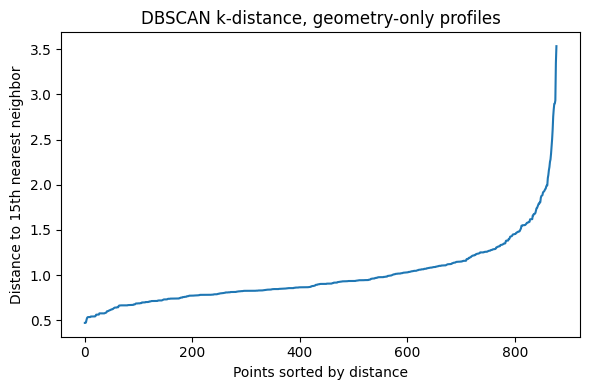

eps=1.2, silhouette_non_noise=nan, sizes={np.int64(-1): np.int64(64), np.int64(0): np.int64(814)}
eps=1.4, silhouette_non_noise=nan, sizes={np.int64(-1): np.int64(20), np.int64(0): np.int64(858)}
eps=1.6, silhouette_non_noise=nan, sizes={np.int64(-1): np.int64(13), np.int64(0): np.int64(865)}
eps=1.8, silhouette_non_noise=nan, sizes={np.int64(-1): np.int64(10), np.int64(0): np.int64(868)}
eps=2.0, silhouette_non_noise=nan, sizes={np.int64(-1): np.int64(3), np.int64(0): np.int64(875)}


,eps,silhouette_non_noise,sizes
0,1.2,NaN,"{-1: 64, 0: 814}"
1,1.4,NaN,"{-1: 20, 0: 858}"
2,1.6,NaN,"{-1: 13, 0: 865}"
3,1.8,NaN,"{-1: 10, 0: 868}"
4,2.0,NaN,"{-1: 3, 0: 875}"


k=2, silhouette=0.323, sizes={np.int64(0): np.int64(660), np.int64(1): np.int64(218)}
k=3, silhouette=0.355, sizes={np.int64(0): np.int64(419), np.int64(1): np.int64(218), np.int64(2): np.int64(241)}
k=4, silhouette=0.344, sizes={np.int64(0): np.int64(218), np.int64(1): np.int64(240), np.int64(2): np.int64(241), np.int64(3): np.int64(179)}
k=5, silhouette=0.328, sizes={np.int64(0): np.int64(241), np.int64(1): np.int64(240), np.int64(2): np.int64(139), np.int64(3): np.int64(179), np.int64(4): np.int64(79)}
k=6, silhouette=0.315, sizes={np.int64(0): np.int64(240), np.int64(1): np.int64(179), np.int64(2): np.int64(139), np.int64(3): np.int64(132), np.int64(4): np.int64(79), np.int64(5): np.int64(109)}


,k,silhouette,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5
0,2,0.323251,660,218,0.0,0.0,0.0,0.0
1,3,0.355357,419,218,241.0,0.0,0.0,0.0
2,4,0.343735,218,240,241.0,179.0,0.0,0.0
3,5,0.327951,241,240,139.0,179.0,79.0,0.0
4,6,0.314784,240,179,139.0,132.0,79.0,109.0


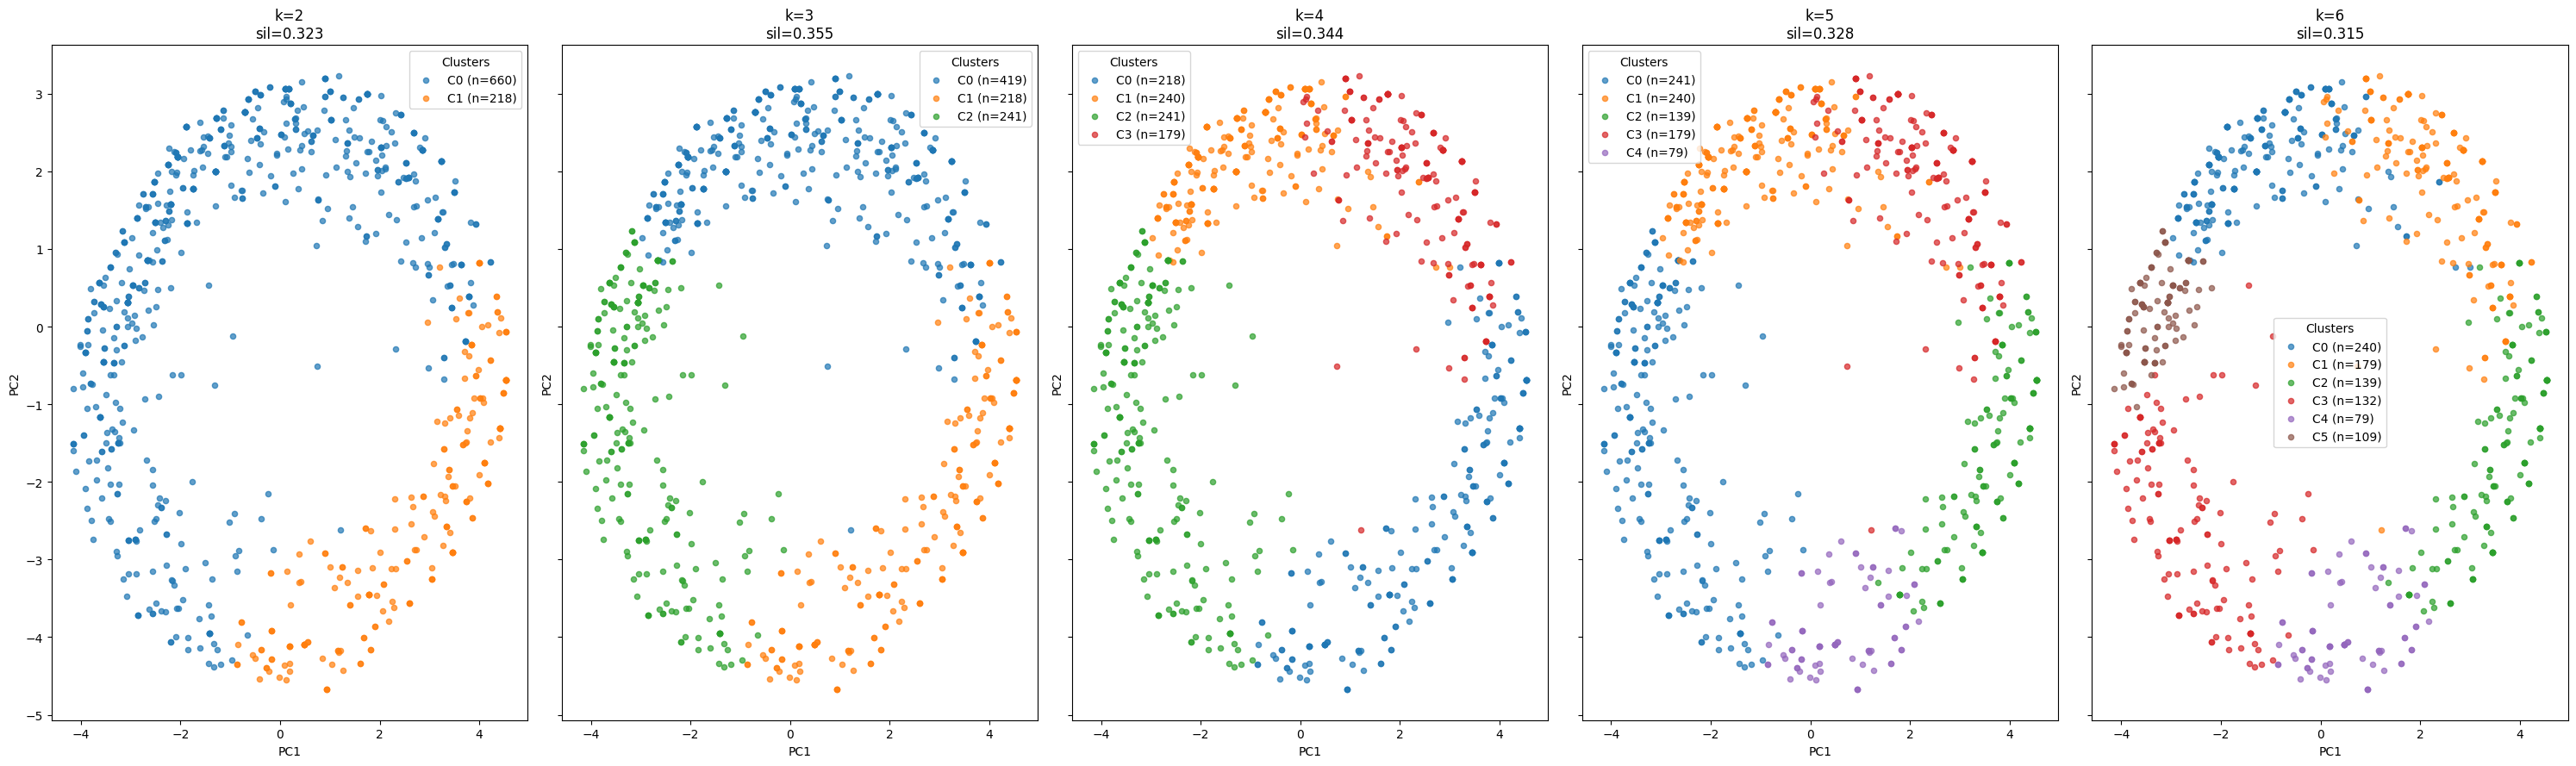

,Feature,k=2,k=3,k=4,k=5,k=6
0,current_surface,0.323,0.355,0.344,0.328,0.315


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score


# ============================================================
# 1. Build fixed-length feature matrix from pseudotime_widths
#    Geometry-only version: profile length is NOT used
# ============================================================

def parse_profile(ts):
    """
    Handles pseudotime_widths stored as list, numpy array, or string.
    """
    if isinstance(ts, np.ndarray):
        return ts.astype(float)

    if isinstance(ts, list):
        return np.asarray(ts, dtype=float)

    if isinstance(ts, str):
        s = (
            ts.replace("\n", " ")
              .replace(",", " ")
              .replace("[", " ")
              .replace("]", " ")
              .strip()
        )
        if s == "":
            return np.array([], dtype=float)
        return np.fromstring(s, sep=" ", dtype=float)

    if pd.isna(ts):
        return np.array([], dtype=float)

    return np.asarray(ts, dtype=float)


def resample_ts_raw(ts, target_len):
    """
    Resample one nucleus-specific confinement-width profile to a fixed length.
    """
    ts = np.asarray(ts, dtype=float)

    if len(ts) < 2:
        raise ValueError("Profile has fewer than 2 points and cannot be resampled.")

    x_old = np.linspace(0, 1, len(ts))
    x_new = np.linspace(0, 1, target_len)

    return np.interp(x_new, x_old, ts)


# Convert profiles
X_series = [parse_profile(ts) for ts in SD_clean["pseudotime_widths"].to_list()]

# Remove invalid/too-short profiles if present
valid_mask = np.array([len(ts) >= 2 for ts in X_series])

if not valid_mask.all():
    print(f"Removing {(~valid_mask).sum()} profiles with fewer than 2 points.")
    SD_clean = SD_clean.loc[valid_mask].copy()
    X_series = [ts for ts, keep in zip(X_series, valid_mask) if keep]

lengths = np.array([len(ts) for ts in X_series], dtype=int)

target_len = int(np.median(lengths))

X_shape = np.vstack([
    resample_ts_raw(ts, target_len)
    for ts in X_series
])

# ------------------------------------------------------------
# IMPORTANT:
# This is the geometry-only clustering input.
# Original profile length is NOT added.
# ------------------------------------------------------------
X_features = X_shape

print("Number of nuclei:", len(SD_clean))
print("Median original profile length, not used as feature:", np.median(lengths))
print("Target resampled length:", target_len)
print("X_shape shape:", X_shape.shape)
print("X_features shape:", X_features.shape)


# ============================================================
# 2. Scale and PCA
# ============================================================

X_scaled = StandardScaler().fit_transform(X_features)

# One deterministic PCA for clustering
n_pcs_cluster = min(5, X_scaled.shape[1], X_scaled.shape[0] - 1)

pca = PCA(n_components=n_pcs_cluster, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

# For plotting: use first 2 PCs from the SAME PCA
X_plot = X_pca[:, :2]

print("X_pca shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Explained variance sum:", pca.explained_variance_ratio_.sum())


# ============================================================
# 3. DBSCAN exploration
# ============================================================

min_samples = 15

nbrs = NearestNeighbors(n_neighbors=min_samples)
nbrs.fit(X_pca)

distances, _ = nbrs.kneighbors(X_pca)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(kdist)
plt.title("DBSCAN k-distance, geometry-only profiles")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.tight_layout()
plt.show()

dbscan_results = []

for eps in [1.2, 1.4, 1.6, 1.8, 2.0]:
    labels = DBSCAN(
        eps=eps,
        min_samples=min_samples
    ).fit_predict(X_pca)

    unique, counts = np.unique(labels, return_counts=True)
    sizes = dict(zip(unique, counts))

    mask = labels != -1

    if len(np.unique(labels[mask])) >= 2:
        sil = silhouette_score(X_pca[mask], labels[mask])
    else:
        sil = np.nan

    dbscan_results.append({
        "eps": eps,
        "silhouette_non_noise": sil,
        "sizes": sizes
    })

    print(f"eps={eps}, silhouette_non_noise={sil}, sizes={sizes}")

dbscan_summary = pd.DataFrame(dbscan_results)
display(dbscan_summary)


# ============================================================
# 4. Agglomerative clustering evaluation
# ============================================================

ks = [2, 3, 4, 5, 6]
results = []

for k in ks:
    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = agg.fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels)

    unique, counts = np.unique(labels, return_counts=True)
    sizes = dict(zip(unique, counts))

    # Store new geometry-only labels without overwriting old columns
    colname = f"cluster_geom_only_k{k}"
    SD_clean[colname] = labels

    results.append({
        "k": k,
        "labels": labels,
        "silhouette": sil,
        "sizes": sizes,
        "colname": colname
    })

    print(f"k={k}, silhouette={sil:.3f}, sizes={sizes}")

agg_summary = pd.DataFrame([
    {
        "k": r["k"],
        "silhouette": r["silhouette"],
        **{f"cluster_{c}": n for c, n in r["sizes"].items()}
    }
    for r in results
]).fillna(0)

display(agg_summary)


# ============================================================
# 5. PCA scatter plots for k=2,3,4,5,6
# ============================================================

fig, axes = plt.subplots(
    1,
    len(ks),
    figsize=(6 * len(ks), 9),
    sharex=True,
    sharey=True
)

if len(ks) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    labels = r["labels"]

    for c in np.unique(labels):
        idx = labels == c
        n_nuclei = np.sum(idx)

        ax.scatter(
            X_plot[idx, 0],
            X_plot[idx, 1],
            s=20,
            alpha=0.7,
            label=f"C{c} (n={n_nuclei})"
        )

    ax.set_title(f"k={r['k']}\nsil={r['silhouette']:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Clusters")

plt.tight_layout()
plt.show()


# ============================================================
# 6. Optional: compact table for manuscript
# ============================================================

surface_name = None

if "Feature_Idx" in SD_clean.columns:
    unique_features = SD_clean["Feature_Idx"].unique()
    if len(unique_features) == 1:
        surface_name = unique_features[0]

manuscript_row = {
    "Feature": surface_name if surface_name is not None else "current_surface"
}

for r in results:
    manuscript_row[f"k={r['k']}"] = round(r["silhouette"], 3)

manuscript_table = pd.DataFrame([manuscript_row])

display(manuscript_table)